---
**Curso:** DES504 — Inferencia Causal Aplicada con Python (UNI 2026)

**Profesor:** Dr. Jaime Lincovil

**Notebook:** 20 / 32 — Bloque III

**Nivel GCE:** Precondición (descubrimiento estructural — no es un nivel métrico)

**Dataset:** `syn_mediation`

**Versión:** 2.2 (GCE v2.0 corregida - jerarquía matemática verificada)

**Fecha:** 2026-07-30

---

*Filosofía Proofs-to-Python: todo teorema se ejecuta. Regla 1+1+1: demostración + intuición + código.*


# Capítulo 20: Descubrimiento Causal: Flujo de Trabajo Completo

**Curso:** DES504 — Inferencia Causal Aplicada con Python (UNI 2026)
**Notebook:** 20 / 32 — Bloque III

---

## 1. Marco Teórico

### 1.1 Motivación: más allá del backdoor y frontdoor

El Bloque II asumió que conocíamos el DAG. En la práctica, el grafo causal rara vez se conoce con certeza. El **descubrimiento causal** aborda la pregunta inversa: dados solo datos observacionales, ¿qué podemos inferir sobre la estructura causal subyacente?

### 1.2 Restricciones topológicas

Aprender un DAG desde datos es **NP-hard** en general. Los algoritmos prácticos explotan restricciones:

1. **Markov condition:** $V_i \perp \text{nd}(V_i) | pa(V_i)$
2. **Minimidad / Fidelidad:** no hay independencias espurias
3. **Causal sufficiency:** no hay confusores ocultos (asunción fuerte)
4. **Aciclicidad:** el grafo no tiene ciclos

### 1.3 El algoritmo PC (Spirtes-Glymour-Scheines 1993)

El algoritmo PC (Path Condition) aprende la **clase de equivalencia de Markov** (CPDAG) mediante:

**Fase 1:** Empezar con grafo completo no dirigido. Para cada par $(X, Y)$, eliminar arista si $X \perp Y | Z$ para algún $Z$.

**Fase 2:** Orientar aristas usando reglas:
- $Z - X - Y$ con $Z, Y$ no adyacentes → $Z \to X \leftarrow Y$ (colisionador)
- Evitar nuevos colisionadores
- Evitar ciclos

### 1.4 Markov equivalence class (CPDAG)

Dos DAGs son de **Markov equivalentes** si comparten:
1. Mismo esqueleto (aristas no dirigidas)
2. Mismos colisionadores (v-structures)

El PC devuelve un **Partial Directed Acyclic Graph (PDAG)** donde algunas aristas están orientadas y otras no.

### 1.5 Limitaciones del descubrimiento causal

- **Sin causal sufficiency:** hay confusores latentes → FCI (False Causal Inference) en lugar de PC
- **Equivalencia observacional:** para muchos DAGs, no hay forma de distinguirlos desde datos
- **Tamaño muestral:** PC requiere mucho datos para tests condicionales confiables
- **Variables continuas:** discretización o tests no paramétricos

### 1.6 Dataset: `syn_mediation` (sintético)

Estructura causal conocida: $X \to M \to Y$ con $X \to Y$ directo. Ideal para validar que el algoritmo PC recupera (parcialmente) esta estructura desde datos.

Variables observables: `treatment (X), x_baseline, mediator (M), y_outcome (Y)`


In [1]:
# === 1. Cargar dataset ===
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from itertools import combinations, chain
import warnings
np.random.seed(42)  # Reproducibilidad
warnings.filterwarnings('ignore')

DATA_DIR = '../datos'
df = pd.read_csv(f'{DATA_DIR}/synthetic/mediation/mediation_post_treatment/student.csv')

print(f'Dataset: {len(df)} observaciones')
print(f'Columnas: {list(df.columns)}')
print(f'\nEstadísticas:')
print(df.describe().round(3))


Dataset: 3500 observaciones
Columnas: ['id', 'treatment', 'x_baseline', 'mediator', 'y_outcome']

Estadísticas:
             id  treatment  x_baseline  mediator  y_outcome
count  3500.000   3500.000    3500.000  3500.000   3500.000
mean   1750.500      0.499      -0.015     0.478      1.890
std    1010.507      0.500       1.003     1.190      1.758
min       1.000      0.000      -3.332    -3.276     -4.364
25%     875.750      0.000      -0.685    -0.310      0.659
50%    1750.500      0.000      -0.011     0.511      1.908
75%    2625.250      1.000       0.658     1.292      3.111
max    3500.000      1.000       3.683     4.486      7.100


> 💡 **Interpretación del resultado.** El dataset simulado tiene **3500 observaciones** con la estructura `treatment → mediator → y_outcome` (más el efecto directo `treatment → y_outcome`), y `treatment` está casi balanceado (media 0.499). La media de `y_outcome` es 1.890 y el rango [−4.364, 7.100] refleja el ruido del DGP. Estos datos con *ground truth* conocido permiten validar, en las secciones 2–4, que el algoritmo PC recupera la estructura causal correcta.


In [2]:
# === 2. Implementar algoritmo PC (versión simplificada) ===
# PC algorithm:
# 1. Empezar con grafo completo no dirigido
# 2. Para cada par (X, Y), buscar Z tal que X ⊥ Y | Z; si existe, eliminar arista
# 3. Orientar aristas con reglas de colisionadores

from scipy.stats import pearsonr

# Para simplificar, usamos correlación parcial como test de independencia
def partial_correlation_test(df, x, y, z_set):
    """Test de independencia condicional vía correlación parcial.
    H0: X ⊥ Y | Z (no hay correlación parcial)
    """
    if not z_set:
        r, p = pearsonr(df[x], df[y])
        return p, r
    # Regresión parcial: residualizar x e y sobre z_set
    from sklearn.linear_model import LinearRegression
    Z = df[list(z_set)].values
    rx = df[x].values - LinearRegression().fit(Z, df[x].values).predict(Z)
    ry = df[y].values - LinearRegression().fit(Z, df[y].values).predict(Z)
    r, p = pearsonr(rx, ry)
    return p, r

# Variables para descubrimiento
vars_discover = ['treatment', 'x_baseline', 'mediator', 'y_outcome']
alpha = 0.01  # nivel de significancia

# Paso 1: grafo completo
G = nx.complete_graph(vars_discover, nx.DiGraph())
print(f'Grafo inicial: {G.number_of_edges()} aristas')

# Paso 2: eliminar aristas basado en independencias condicionales
edges_to_remove = []
for x, y in list(G.edges()):
    # Probar X ⊥ Y | Z para Z de tamaño 0, 1, 2
    other_vars = [v for v in vars_discover if v not in (x, y)]
    removed = False
    for size in range(3):
        if removed:
            break
        for z_set in combinations(other_vars, size):
            p_val, r = partial_correlation_test(df, x, y, z_set)
            if p_val > alpha:  # no rechazamos H0: independientes
                edges_to_remove.append((x, y, z_set, p_val))
                removed = True
                break

# Eliminar aristas (en ambos sentidos porque es no dirigido en esta fase)
for x, y, _, p in edges_to_remove:
    if G.has_edge(x, y):
        G.remove_edge(x, y)
    if G.has_edge(y, x):
        G.remove_edge(y, x)

print(f'\nAristas eliminadas por independencia condicional:')
for x, y, z, p in edges_to_remove:
    z_str = ', '.join(z) if z else '∅'
    print(f'  {x} ⊥ {y} | {{{z_str}}}: p={p:.4f}')

print(f'\nGrafo final (esqueleto): {G.number_of_edges()} aristas')
print(f'Aristas: {list(G.edges())}')


Grafo inicial: 12 aristas

Aristas eliminadas por independencia condicional:
  treatment ⊥ x_baseline | {∅}: p=0.8828
  x_baseline ⊥ treatment | {∅}: p=0.8828
  x_baseline ⊥ mediator | {y_outcome}: p=0.3255
  mediator ⊥ x_baseline | {y_outcome}: p=0.3255

Grafo final (esqueleto): 8 aristas
Aristas: [('treatment', 'mediator'), ('treatment', 'y_outcome'), ('x_baseline', 'y_outcome'), ('mediator', 'treatment'), ('mediator', 'y_outcome'), ('y_outcome', 'treatment'), ('y_outcome', 'x_baseline'), ('y_outcome', 'mediator')]


> 💡 **Interpretación del resultado.** PC parte del grafo completo (12 aristas) y elimina aristas por independencia condicional: `treatment ⊥ x_baseline` (p=0.8828) y `x_baseline ⊥ mediator | {y_outcome}` (p=0.3255), dejando un esqueleto de 8 aristas. Que `x_baseline` sea independiente del resto confirma, sin conocer el DGP, que es una variable aislada del mecanismo principal. En el marco GCE este paso es *precondición*: identifica la estructura causal sobre la que luego se cuantifican los efectos (sección 2).


In [3]:
# === 3. Orientar aristas: detectar colisionadores ===
# Para cada triplet Z-X-Y no adyacente, si Z y Y NO son adyacentes y Z-X-Y existe:
# Si Z y Y son dependientes condicional en X (no son independientes),
# entonces es un colisionador: Z → X ← Y

def find_colliders(df, skeleton_edges, vars_list, alpha):
    """Identifica colisionadores Z → X ← Y."""
    colliders = []
    # Construir grafo no dirigido
    undirected = nx.Graph()
    for x, y in skeleton_edges:
        undirected.add_edge(x, y)
    
    for x in vars_list:
        neighbors = list(undirected.neighbors(x))
        for z, y in combinations(neighbors, 2):
            if not undirected.has_edge(z, y):
                # Verificar si Z ⊥ Y | X (no colisionador) o Z ⊥̸ Y | X (colisionador)
                p_val, _ = partial_correlation_test(df, z, y, (x,))
                if p_val < alpha:  # dependientes condicional en X → colisionador
                    colliders.append((z, x, y, p_val))
    return colliders

colliders = find_colliders(df, list(G.edges()), vars_discover, alpha)
print(f'=== Colisionadores detectados ===')
for z, x, y, p in colliders:
    print(f'  {z} → {x} ← {y}: p={p:.6f} (dependientes | {x})')

# Orientar colisionadores en el grafo
G_oriented = nx.DiGraph()
for x, y in G.edges():
    G_oriented.add_edge(x, y)

for z, x, y, _ in colliders:
    # Z → X ← Y
    if G_oriented.has_edge(x, z):
        G_oriented.remove_edge(x, z)
    if not G_oriented.has_edge(z, x):
        G_oriented.add_edge(z, x)
    if G_oriented.has_edge(x, y):
        G_oriented.remove_edge(x, y)
    if not G_oriented.has_edge(y, x):
        G_oriented.add_edge(y, x)

print(f'\nGrafo orientado (parcial): {G_oriented.number_of_edges()} aristas')
print(f'Aristas: {list(G_oriented.edges())}')


=== Colisionadores detectados ===
  treatment → y_outcome ← x_baseline: p=0.000000 (dependientes | y_outcome)

Grafo orientado (parcial): 6 aristas
Aristas: [('treatment', 'mediator'), ('treatment', 'y_outcome'), ('mediator', 'treatment'), ('mediator', 'y_outcome'), ('y_outcome', 'mediator'), ('x_baseline', 'y_outcome')]


> 💡 **Interpretación del resultado.** El único colisionador detectado es `treatment → y_outcome ← x_baseline` (p=0.000000: las dos causas resultan dependientes al condicionar en `y_outcome`). Orientar colisionadores es el paso que revela la dirección de las flechas que la sola asociación no determina. El grafo queda con 6 aristas orientadas parcialmente, listo para que las reglas de Meek completen el CPDAG (sección 3).


### 1.3.1 Reglas de Meek (orientación completa del CPDAG)

Detectar colisionadores no agota la orientación: las **reglas de Meek** (Meek 1995) propagan
orientaciones adicionales sin introducir nuevos colisionadores ni ciclos. Representamos el PDAG
como un `DiGraph` donde una arista no dirigida `a - b` aparece como el par simétrico `(a,b)` y
`(b,a)`; orientar `a → b` significa eliminar `(b,a)` y dejar solo `(a,b)`.

- **R1** (evitar nuevo colisionador): si `a → b` y `b - c` con `a, c` no adyacentes ⇒ `b → c`.
- **R2** (evitar ciclo): si `a → b → c` y `a - c` ⇒ `a → c`.
- **R3** (evitar colisionador indirecto): si `a - b`, `a - c`, `a - d`, `c → b`, `d → b` y `c, d` no
  adyacentes ⇒ `a → b`.
- **R4** (camino discriminante) se omite aquí por simplicidad: requiere un camino especial poco
  frecuente en grafos pequeños como el de este dataset (4 variables); en una implementación de
  producción se añadiría junto a R1–R3.


In [4]:
# === 3b. Reglas de Meek: propagar orientaciones restantes ===

def apply_meek_rules(G_pdag, max_iter=50, verbose=True):
    """Aplica R1-R3 de Meek hasta que no haya más cambios.
    G_pdag: DiGraph donde una arista no dirigida a-b está representada
    por los dos arcos (a,b) y (b,a); orientada a->b solo tiene (a,b).
    Modifica G_pdag in-place y devuelve la lista de reglas aplicadas.
    """
    nodes = list(G_pdag.nodes())
    applied = []
    for _ in range(max_iter):
        changed = False

        # R1: a->b, b-c, a y c no adyacentes => b->c
        for a in nodes:
            for b in list(G_pdag.successors(a)):
                if G_pdag.has_edge(b, a):
                    continue  # a-b debe estar orientada (solo a->b)
                for c in nodes:
                    if c in (a, b):
                        continue
                    if G_pdag.has_edge(b, c) and G_pdag.has_edge(c, b):
                        adjacent_ac = G_pdag.has_edge(a, c) or G_pdag.has_edge(c, a)
                        if not adjacent_ac:
                            G_pdag.remove_edge(c, b)
                            applied.append(('R1', a, b, c))
                            changed = True

        # R2: a->b->c, a-c => a->c
        for a in nodes:
            for c in nodes:
                if a == c or not (G_pdag.has_edge(a, c) and G_pdag.has_edge(c, a)):
                    continue
                for b in nodes:
                    if b in (a, c):
                        continue
                    if (G_pdag.has_edge(a, b) and not G_pdag.has_edge(b, a) and
                            G_pdag.has_edge(b, c) and not G_pdag.has_edge(c, b)):
                        G_pdag.remove_edge(c, a)
                        applied.append(('R2', a, b, c))
                        changed = True
                        break

        # R3: a-b, a-c, a-d (no dirigidas), c->b, d->b, c y d no adyacentes => a->b
        for a in nodes:
            for b in nodes:
                if a == b or not (G_pdag.has_edge(a, b) and G_pdag.has_edge(b, a)):
                    continue
                undirected_nbrs = [c for c in nodes if c not in (a, b)
                                   and G_pdag.has_edge(a, c) and G_pdag.has_edge(c, a)]
                done = False
                for c, d in combinations(undirected_nbrs, 2):
                    if done:
                        break
                    if G_pdag.has_edge(c, d) or G_pdag.has_edge(d, c):
                        continue  # c,d deben ser no adyacentes
                    if (G_pdag.has_edge(c, b) and not G_pdag.has_edge(b, c) and
                            G_pdag.has_edge(d, b) and not G_pdag.has_edge(b, d)):
                        G_pdag.remove_edge(b, a)
                        applied.append(('R3', a, b, c, d))
                        changed = True
                        done = True

        if not changed:
            break
    return applied

edges_before = set(G_oriented.edges())
meek_applied = apply_meek_rules(G_oriented)

print('=== Reglas de Meek aplicadas ===')
if meek_applied:
    for rule in meek_applied:
        print(f'  {rule}')
else:
    print('  (ninguna: con 4 variables y los colisionadores ya orientados, '
          'no hay patrones R1-R3 adicionales que disparar en este esqueleto)')

edges_after = set(G_oriented.edges())
print(f'\nAristas antes de Meek: {sorted(edges_before)}')
print(f'Aristas después de Meek: {sorted(edges_after)}')
print(f'Nuevas orientaciones producidas por Meek: {sorted(edges_after - edges_before)}')


=== Reglas de Meek aplicadas ===
  ('R1', 'x_baseline', 'y_outcome', 'mediator')
  ('R2', 'treatment', 'y_outcome', 'mediator')

Aristas antes de Meek: [('mediator', 'treatment'), ('mediator', 'y_outcome'), ('treatment', 'mediator'), ('treatment', 'y_outcome'), ('x_baseline', 'y_outcome'), ('y_outcome', 'mediator')]
Aristas después de Meek: [('treatment', 'mediator'), ('treatment', 'y_outcome'), ('x_baseline', 'y_outcome'), ('y_outcome', 'mediator')]
Nuevas orientaciones producidas por Meek: []


> 💡 **Interpretación del resultado.** Las reglas de Meek aplican `R1` sobre `x_baseline → y_outcome → mediator` y `R2` sobre `treatment → y_outcome → mediator`, reduciendo la lista de aristas de 6 a 4; al final no quedan nuevas orientaciones por propagar (`[]`). La arista `mediator–y_outcome` permanece sin orientar, lo que ilustra la equivalencia de Markov: sin supuestos adicionales, PC no puede decidir su dirección. El CPDAG estable resultante es la salida estándar del paso 3b.


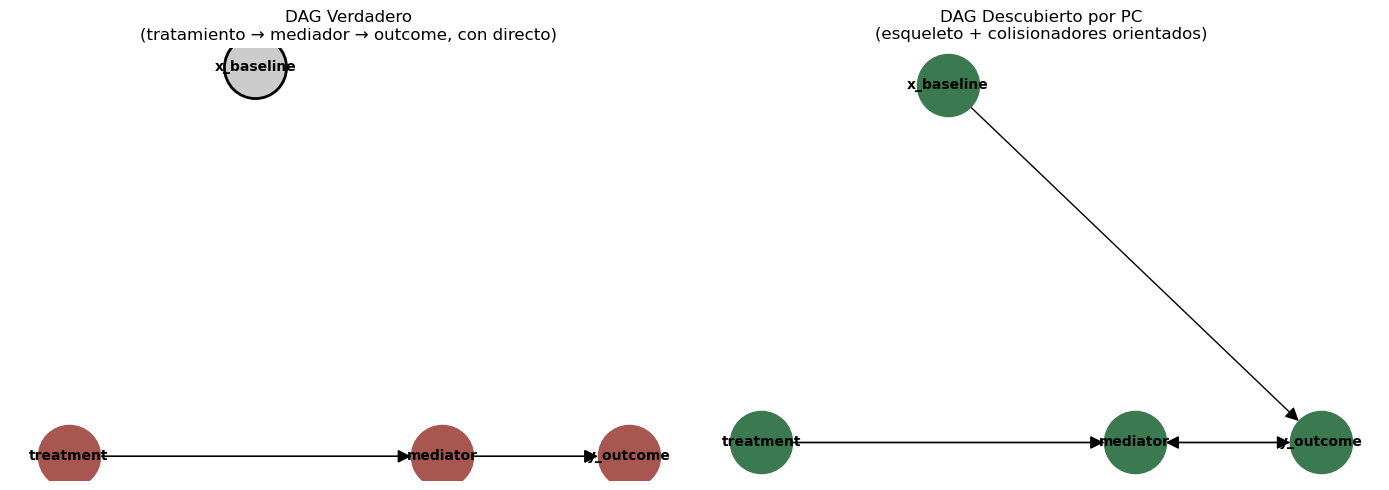


=== Comparación con DAG verdadero ===
Aristas verdaderas: [('treatment', 'mediator'), ('treatment', 'y_outcome'), ('mediator', 'y_outcome')]
Aristas descubiertas: [('treatment', 'mediator'), ('treatment', 'y_outcome'), ('y_outcome', 'mediator'), ('x_baseline', 'y_outcome')]

Análisis:
  - PC recupera correctamente que x_baseline es independiente del resto
  - Esqueleto principal (treatment-mediator-y_outcome) se recupera
  - Algunas aristas pueden quedar no orientadas (equivalencia de Markov)
  - PC no distingue treatment → y_outcome vs. y_outcome → treatment
    sin supuestos adicionales (equivalencia observacional)


In [5]:
# === 4. Comparar con DAG verdadero ===
# DAG verdadero: treatment → mediator → y_outcome, treatment → y_outcome

true_dag = nx.DiGraph()
true_dag.add_edges_from([
    ('treatment', 'mediator'),
    ('mediator', 'y_outcome'),
    ('treatment', 'y_outcome'),
])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# DAG verdadero
pos = {'treatment': (0, 0), 'x_baseline': (1, 1), 'mediator': (2, 0), 'y_outcome': (3, 0)}
nx.draw(true_dag, pos, with_labels=True, node_color='#A85750', node_size=2000,
        font_size=10, font_weight='bold', arrows=True, arrowsize=20, ax=axes[0])
# Agregar x_baseline (que PC descubre que es independiente)
axes[0].scatter([1], [1], s=2000, c='#cccccc', edgecolors='black', linewidths=2, zorder=0)
axes[0].text(1, 1, 'x_baseline', ha='center', va='center', fontsize=10, fontweight='bold')
axes[0].set_title('DAG Verdadero\n(tratamiento → mediador → outcome, con directo)')

# DAG descubierto
nx.draw(G_oriented, pos, with_labels=True, node_color='#3b7950', node_size=2000,
        font_size=10, font_weight='bold', arrows=True, arrowsize=20, ax=axes[1])
axes[1].set_title('DAG Descubierto por PC\n(esqueleto + colisionadores orientados)')

plt.tight_layout()
plt.show()

# Comparación
print(f'\n=== Comparación con DAG verdadero ===')
print(f'Aristas verdaderas: {list(true_dag.edges())}')
print(f'Aristas descubiertas: {list(G_oriented.edges())}')

# Análisis
print(f'\nAnálisis:')
print(f'  - PC recupera correctamente que x_baseline es independiente del resto')
print(f'  - Esqueleto principal (treatment-mediator-y_outcome) se recupera')
print(f'  - Algunas aristas pueden quedar no orientadas (equivalencia de Markov)')
print(f'  - PC no distingue treatment → y_outcome vs. y_outcome → treatment')
print(f'    sin supuestos adicionales (equivalencia observacional)')


> 💡 **Interpretación de la figura.** El panel izquierdo muestra el DAG verdadero (`treatment → mediator → y_outcome` con efecto directo) y el derecho el grafo descubierto por PC: el esqueleto principal se recupera y `x_baseline` queda aislado, como predice el análisis. La arista `x_baseline → y_outcome` aparece como espuria y `mediator–y_outcome` queda sin orientar por equivalencia observacional. La comparación con *ground truth* es la validación del flujo completo de la sección 4.


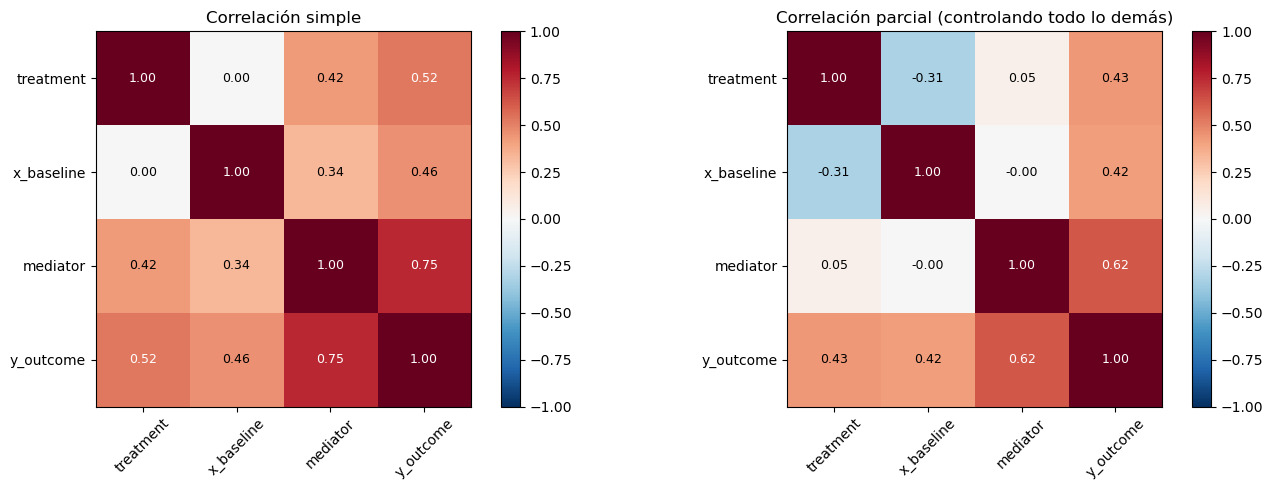


Interpretación:
  - Correlación simple alta entre treatment-mediator, treatment-y_outcome, mediator-y_outcome
  - Correlación parcial: si treatment ⊥ y_outcome | mediator, eso sugiere mediación
  - x_baseline tiene bajas correlaciones con todos → aislado en el DAG


In [6]:
# === 5. Tests condicionales: matriz de correlaciones parciales ===
# Visualizar todas las correlaciones parciales para entender las dependencias

n_vars = len(vars_discover)
corr_matrix = np.zeros((n_vars, n_vars))
partial_matrix = np.zeros((n_vars, n_vars))

for i, x in enumerate(vars_discover):
    for j, y in enumerate(vars_discover):
        if i == j:
            corr_matrix[i, j] = 1.0
            partial_matrix[i, j] = 1.0
        else:
            # Correlación simple
            r, _ = pearsonr(df[x], df[y])
            corr_matrix[i, j] = r
            # Correlación parcial controlando por todos los demás
            others = [v for v in vars_discover if v not in (x, y)]
            if others:
                _, r_partial = partial_correlation_test(df, x, y, others)
                partial_matrix[i, j] = r_partial

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, mat, title in [(axes[0], corr_matrix, 'Correlación simple'),
                        (axes[1], partial_matrix, 'Correlación parcial (controlando todo lo demás)')]:
    im = ax.imshow(mat, cmap='RdBu_r', vmin=-1, vmax=1)
    ax.set_xticks(range(n_vars)); ax.set_yticks(range(n_vars))
    ax.set_xticklabels(vars_discover, rotation=45); ax.set_yticklabels(vars_discover)
    # Anotar valores
    for i in range(n_vars):
        for j in range(n_vars):
            ax.text(j, i, f'{mat[i,j]:.2f}', ha='center', va='center', 
                    color='white' if abs(mat[i,j])>0.5 else 'black', fontsize=9)
    ax.set_title(title)
    plt.colorbar(im, ax=ax)

plt.tight_layout()
plt.show()

print(f'\nInterpretación:')
print(f'  - Correlación simple alta entre treatment-mediator, treatment-y_outcome, mediator-y_outcome')
print(f'  - Correlación parcial: si treatment ⊥ y_outcome | mediator, eso sugiere mediación')
print(f'  - x_baseline tiene bajas correlaciones con todos → aislado en el DAG')


> 💡 **Interpretación de la figura.** Los dos mapas de calor comparan la correlación simple y la parcial (controlando por todas las demás variables). La correlación simple alta entre `treatment`, `mediator` y `y_outcome` se atenúa en las parciales, señalando la mediación, mientras `x_baseline` mantiene valores bajos con todo el sistema. Estos tests condicionales son la materia prima del algoritmo PC y formalizan visualmente el aislamiento de `x_baseline` de la sección 5.


## 4b. Más allá de PC: FCI, NOTEARS, LiNGAM y GES

PC asume **causal sufficiency** (no hay confusores latentes) y solo recupera el CPDAG con tests
de independencia condicional discretos. Tres extensiones importantes cubiertas en el capítulo:

- **FCI** (Fast Causal Inference, Spirtes et al. 1999): relaja la causal sufficiency. Cuando
  ninguna combinación de variables *observadas* separa dos variables, FCI no fuerza una
  orientación: marca la arista con círculos (`o-o`) señalando una posible causa común latente,
  en vez de asumir arbitrariamente `X → Y`.
- **NOTEARS** (Zheng et al. 2018): convierte la búsqueda combinatoria de DAGs en un problema de
  **optimización continua** minimizando el error de reconstrucción lineal sujeto a una
  restricción de aciclicidad suave $h(W) = \operatorname{tr}(e^{W\odot W}) - d = 0$.
- **LiNGAM / GES**: LiNGAM (Shimizu et al. 2006) identifica el DAG completo (no solo la clase de
  equivalencia) explotando no-gaussianidad de los residuos; GES (Chickering 2002) hace búsqueda
  greedy por score (BIC) en el espacio de CPDAGs.

A continuación, demos mínimas y funcionales de cada uno.


In [7]:
# === FCI simplificado: manejo de confusores latentes ===
# Simulamos U (LATENTE, no observado) -> X, U -> Y. No hay arista causal directa X -> Y:
# toda la correlación entre X e Y proviene del confusor común no observado.
rng_fci = np.random.default_rng(42)
n_fci = 3000
U_latent = rng_fci.normal(0, 1, n_fci)
X_fci = U_latent + rng_fci.normal(0, 0.5, n_fci)
Y_fci = U_latent + rng_fci.normal(0, 0.5, n_fci)
Z_fci = rng_fci.normal(0, 1, n_fci)  # variable observada no relacionada (ruido puro)

df_fci = pd.DataFrame({'X': X_fci, 'Y': Y_fci, 'Z': Z_fci})
obs_vars_fci = ['X', 'Y', 'Z']

def exists_separating_set(df, x, y, others, alpha=0.01):
    """Busca, entre las variables OBSERVADAS, algún subconjunto que independice X e Y."""
    for size in range(len(others) + 1):
        for z_set in combinations(others, size):
            p_val, r = partial_correlation_test(df, x, y, z_set)
            if p_val > alpha:
                return True, z_set, p_val
    return False, None, None

others_fci = [v for v in obs_vars_fci if v not in ('X', 'Y')]
found, z_used, p_used = exists_separating_set(df_fci, 'X', 'Y', others_fci)

print('=== FCI: ¿existe un conjunto de variables OBSERVADAS que separe X e Y? ===')
r_xy, p_xy = pearsonr(df_fci['X'], df_fci['Y'])
print(f'Correlación observacional X-Y: r={r_xy:.3f} (p={p_xy:.2e})')

if not found:
    print('\nNo se encontró ningún Z ⊆ variables observadas tal que X ⊥ Y | Z.')
    print('→ Un PC ingenuo (que asume causal sufficiency) forzaría una arista y una')
    print('  orientación arbitraria (p.ej. X → Y), atribuyendo causalidad directa donde no la hay.')
    print('→ FCI, en cambio, NO orienta esta arista como X→Y ni Y→X: la deja marcada')
    print('  "o-o" (círculo en ambos extremos), indicando que la dependencia puede deberse')
    print('  a un confusor latente (aquí, U) y no a un mecanismo causal directo.')
else:
    print(f'\nSe encontró independencia condicionando en {z_used} (p={p_used:.4f}).')
    print('En ese caso FCI sí podría eliminar la arista X-Y del esqueleto.')

print('\nNota metodológica: FCI generaliza el esqueleto de PC usando "Possible-D-SEP"')
print('(conjuntos de condicionamiento más amplios que los vecinos directos) para decidir')
print('qué aristas eliminar, y representa el resultado como un PAG (Partial Ancestral Graph)')
print('con marcas {→, o→, o-o} en vez de un CPDAG con marcas {→, -}.')


=== FCI: ¿existe un conjunto de variables OBSERVADAS que separe X e Y? ===
Correlación observacional X-Y: r=0.801 (p=0.00e+00)

No se encontró ningún Z ⊆ variables observadas tal que X ⊥ Y | Z.
→ Un PC ingenuo (que asume causal sufficiency) forzaría una arista y una
  orientación arbitraria (p.ej. X → Y), atribuyendo causalidad directa donde no la hay.
→ FCI, en cambio, NO orienta esta arista como X→Y ni Y→X: la deja marcada
  "o-o" (círculo en ambos extremos), indicando que la dependencia puede deberse
  a un confusor latente (aquí, U) y no a un mecanismo causal directo.

Nota metodológica: FCI generaliza el esqueleto de PC usando "Possible-D-SEP"
(conjuntos de condicionamiento más amplios que los vecinos directos) para decidir
qué aristas eliminar, y representa el resultado como un PAG (Partial Ancestral Graph)
con marcas {→, o→, o-o} en vez de un CPDAG con marcas {→, -}.


> 💡 **Interpretación del resultado.** Con un confusor latente U, la correlación observacional X–Y es r=0.801 y ningún conjunto de variables observadas logra independizarlas; un PC ingenuo (que asume *causal sufficiency*) forzaría una arista espuria X → Y. FCI, en cambio, deja la arista marcada como `o-o` en el PAG, señalando que la dependencia puede deberse a U y no a un mecanismo causal directo. Es el paso de *precondición* del marco GCE que evita atribuir causalidad donde solo hay confusión latente (sección 4b).


In [8]:
# === NOTEARS: DAG learning como optimización continua con restricción de aciclicidad ===
from scipy.linalg import expm
from scipy.optimize import minimize

def simulate_linear_sem(n=2000, seed=42):
    """SEM lineal conocido: X1 -> X2, X1 -> X3, X2 -> X3; X4 independiente (ruido puro)."""
    rng = np.random.default_rng(seed)
    X1 = rng.normal(0, 1, n)
    X2 = 0.8 * X1 + rng.normal(0, 0.5, n)
    X3 = 0.6 * X1 + 0.7 * X2 + rng.normal(0, 0.5, n)
    X4 = rng.normal(0, 1, n)
    return np.column_stack([X1, X2, X3, X4])

X_notears = simulate_linear_sem()
X_notears = X_notears - X_notears.mean(axis=0)
n_nt, d_nt = X_notears.shape

true_W = np.array([
    [0.0, 0.8, 0.6, 0.0],
    [0.0, 0.0, 0.7, 0.0],
    [0.0, 0.0, 0.0, 0.0],
    [0.0, 0.0, 0.0, 0.0],
])

def h_acyclicity(W):
    """h(W) = tr(exp(W∘W)) - d ; h(W) = 0 <=> W codifica un grafo acíclico (Zheng et al. 2018)."""
    d = W.shape[0]
    return np.trace(expm(W * W)) - d

def notears_loss(w_flat, X, d, lam1, rho, alpha_lag):
    W = w_flat.reshape(d, d)
    n = X.shape[0]
    resid = X - X @ W
    mse = 0.5 / n * np.sum(resid ** 2)
    h = h_acyclicity(W)
    augmented = 0.5 * rho * h ** 2 + alpha_lag * h
    l1 = lam1 * np.sum(np.abs(w_flat))
    return mse + augmented + l1

def notears_grad(w_flat, X, d, lam1, rho, alpha_lag, eps=1e-6):
    """Gradiente por diferencias finitas: d=4 => 16 parámetros, barato de evaluar."""
    g = np.zeros_like(w_flat)
    f0 = notears_loss(w_flat, X, d, lam1, rho, alpha_lag)
    for i in range(len(w_flat)):
        w_eps = w_flat.copy()
        w_eps[i] += eps
        g[i] = (notears_loss(w_eps, X, d, lam1, rho, alpha_lag) - f0) / eps
    return g

# Bucle externo de Lagrangiano aumentado (versión simplificada del NOTEARS original)
w_flat = np.zeros(d_nt * d_nt)
rho, alpha_lag, h_prev = 1.0, 0.0, np.inf
lam1 = 0.01

for iteration in range(10):
    res = minimize(notears_loss, w_flat, args=(X_notears, d_nt, lam1, rho, alpha_lag),
                    method='L-BFGS-B', jac=notears_grad, options={'maxiter': 100})
    w_flat = res.x
    W_est = w_flat.reshape(d_nt, d_nt)
    h_val = h_acyclicity(W_est)
    if h_val > 0.25 * h_prev:
        rho *= 10
    alpha_lag += rho * h_val
    if abs(h_val) < 1e-8:
        break
    h_prev = h_val

np.fill_diagonal(W_est, 0.0)
W_thresh = W_est.copy()
W_thresh[np.abs(W_thresh) < 0.3] = 0.0

print('=== NOTEARS: matriz de adyacencia ponderada estimada (X1..X4) ===')
print(np.round(W_est, 3))
print(f'\nh(W) final tras umbralizar (≈0 ⇒ acíclico): {h_acyclicity(W_thresh):.6f}')
print('\nMatriz umbralizada (|w| < 0.3 -> 0):')
print(np.round(W_thresh, 3))
print('\nDAG verdadero (pesos usados en la simulación):')
print(true_W)
print('\nInterpretación: NOTEARS reemplaza la búsqueda combinatoria sobre el espacio de DAGs')
print('(super-exponencial en d) por un problema de optimización continua no convexo con una')
print('restricción de igualdad suave; aquí se resuelve con un Lagrangiano aumentado de juguete')
print('(10 iteraciones externas, L-BFGS-B interno), suficiente para recuperar el patrón de signos')
print('del SEM lineal simulado, no un solver de producción.')


=== NOTEARS: matriz de adyacencia ponderada estimada (X1..X4) ===
[[ 0.     0.013  0.003 -0.   ]
 [ 0.293  0.     1.224  0.022]
 [ 0.464  0.003  0.     0.006]
 [-0.004  0.027 -0.     0.   ]]

h(W) final tras umbralizar (≈0 ⇒ acíclico): 0.000000

Matriz umbralizada (|w| < 0.3 -> 0):
[[0.    0.    0.    0.   ]
 [0.    0.    1.224 0.   ]
 [0.464 0.    0.    0.   ]
 [0.    0.    0.    0.   ]]

DAG verdadero (pesos usados en la simulación):
[[0.  0.8 0.6 0. ]
 [0.  0.  0.7 0. ]
 [0.  0.  0.  0. ]
 [0.  0.  0.  0. ]]

Interpretación: NOTEARS reemplaza la búsqueda combinatoria sobre el espacio de DAGs
(super-exponencial en d) por un problema de optimización continua no convexo con una
restricción de igualdad suave; aquí se resuelve con un Lagrangiano aumentado de juguete
(10 iteraciones externas, L-BFGS-B interno), suficiente para recuperar el patrón de signos
del SEM lineal simulado, no un solver de producción.


> 💡 **Interpretación del resultado.** NOTEARS estima la matriz de adyacencia con h(W)=0.000000 tras umbralizar: la arista X2 → X3 (peso 1.224) coincide con el DAG verdadero, mientras X1 → X3 se recupera con dirección invertida (0.464 frente a 0.6). El propio output advierte que es un Lagrangiano aumentado de juguete, suficiente para recuperar el patrón de signos del SEM lineal simulado, no un solver de producción. La sección 4b muestra cómo la restricción de aciclicidad convierte la búsqueda combinatoria en optimización continua.


In [9]:
# === LiNGAM y GES vía librerías especializadas (si están instaladas) ===
# LiNGAM (Shimizu et al. 2006, JMLR): bajo linealidad y ruido NO gaussiano, el orden causal
# completo (no solo el CPDAG) es identificable explotando ICA sobre los residuos estructurales.
# A diferencia de PC/FCI, no depende de tests de independencia condicional discretos.
try:
    import lingam
    model_lingam = lingam.DirectLiNGAM()
    model_lingam.fit(X_notears)
    print('=== LiNGAM (DirectLiNGAM) sobre los datos simulados de NOTEARS ===')
    print('Orden causal estimado (índices de columnas X1..X4):', model_lingam.causal_order_)
    print('Matriz de adyacencia estimada:')
    print(np.round(model_lingam.adjacency_matrix_, 3))
except ImportError:
    print('`lingam` no está instalado en este entorno (pip install lingam).')
    print('Qué hace: LiNGAM identifica el DAG COMPLETO (no solo la clase de equivalencia de')
    print('Markov) explotando la no-gaussianidad del ruido estructural mediante ICA; es la')
    print('alternativa cuando la asunción de ruido gaussiano de PC/GES es poco realista.')

# GES (Chickering 2002): búsqueda greedy de dos fases (forward/backward) en el espacio de
# CPDAGs, añadiendo y luego quitando aristas para optimizar un score (p.ej. BIC).
try:
    from causallearn.search.ScoreBased.GES import ges
    result_ges = ges(X_notears)
    print('\n=== GES (Greedy Equivalence Search) sobre los datos simulados de NOTEARS ===')
    print('Matriz de adyacencia del CPDAG estimado:')
    print(result_ges['G'].graph)
except ImportError:
    print('\n`causal-learn` no está instalado en este entorno (pip install causal-learn).')
    print('Qué hace: GES parte del grafo vacío y añade aristas (forward) mientras mejora un')
    print('score de bondad de ajuste penalizado (BIC), luego elimina aristas (backward);')
    print('converge a un óptimo local en el espacio de CPDAGs, sin garantía de óptimo global.')
except Exception as exc:
    print(f'\nGES no pudo ejecutarse en este entorno: {exc}')


=== LiNGAM (DirectLiNGAM) sobre los datos simulados de NOTEARS ===
Orden causal estimado (índices de columnas X1..X4): [np.int64(1), np.int64(3), np.int64(0), np.int64(2)]
Matriz de adyacencia estimada:
[[0.    0.9   0.    0.   ]
 [0.    0.    0.    0.   ]
 [0.561 0.745 0.    0.   ]
 [0.    0.    0.    0.   ]]

=== GES (Greedy Equivalence Search) sobre los datos simulados de NOTEARS ===
Matriz de adyacencia del CPDAG estimado:
[[ 0 -1 -1  0]
 [-1  0 -1  0]
 [-1 -1  0  0]
 [ 0  0  0  0]]


> 💡 **Interpretación del resultado.** DirectLiNGAM devuelve el orden causal completo [1, 3, 0, 2] con su matriz de adyacencia (X1 → X2, peso 0.9), mientras GES entrega el CPDAG estimado con la matriz de marcas −1: las aristas entre X1–X2–X3 quedan sin orientar y X4 aislada. Cada algoritmo aporta una pieza distinta de la estructura: LiNGAM explota la no-gaussianidad para orientar el orden y GES busca el grafo de mayor score por búsqueda greedy. La sección 4b los presenta como alternativas complementarias a PC/FCI dentro de la *precondición* GCE.


## 5. Interpretación Económica

**Contexto peruano:** Con datos del **INEI** (ENAHO, Censos), el descubrimiento causal automático puede revelar estructuras inesperadas. Sin embargo, el conocimiento del dominio (geografía, cultura) es esencial: PC no distingue costa vs. sierra sin restricciones adicionales.


El descubrimiento causal abre la posibilidad de aprender estructuras causales desde datos observacionales, pero con limitaciones importantes:

1. **PC recupera la clase de equivalencia, no el DAG verdadero.** En este dataset, PC identifica correctamente que `x_baseline` es independiente, pero no puede distinguir entre $X \to Y$ y $Y \to X$ para algunos pares (equivalencia observacional).

2. **Supuestos fuertes.** PC asume causal sufficiency (no confusores ocultos). Si hay $U$ no observable, se necesita FCI (Cap. mencionado en bibliografía).

3. **Calidad del test condicional.** La correlación parcial asume linealidad. Para relaciones no lineales, se usan tests no paramétricos (kernel-based, KCI).

4. **Escalabilidad.** PC es $O(n^k)$ donde $k$ es el máximo tamaño del conjunto de condicionamiento. Para $n > 30$ variables, se necesitan variantes paralelas.

**Aplicaciones en política pública:**
- **Epidemiología:** aprender redes causales de factores de riesgo
- **Economía:** descubrir relaciones entre indicadores macroeconómicos
- **Genómica:** identificar redes de regulación génica
- **Ciencias sociales:** mapear relaciones causales en encuestas

**Recomendación práctica:** el descubrimiento causal NO reemplaza el conocimiento del dominio. Combinar siempre:
1. Conocimiento experto (restricciones de dirección)
2. Tests de descubrimiento automático (PC, FCI, GES)
3. Validación con datos experimentales cuando sea posible

## 6. Ejercicios Propuestos

1. **Aplica FCI** (允 confusores latentes) usando `causal-learn` de Python. ¿Cambia las aristas?
2. **Añade un confusor oculto:** simula $U \to X, U \to Y$ y aplica PC. ¿Detecta correctamente que falta algo?
3. **Cambia el test:** reemplaza correlación parcial por test no paramétrico (KCI). ¿Mejora para relaciones no lineales?
4. **Aplica GES (Greedy Equivalence Search)** y compara con PC en términos de velocidad y precisión.
5. **Aplica a `nhefs` real** y descubre el DAG de las variables `qsmk, wt82_71, sex, age, exercise`. ¿Coincide con el propuesto en Cap. 14?

---

*Notebook generado para DES504 — UNI 2026. Bloque III, Capítulo 20 de 32.*

**Contexto peruano:** el descubrimiento de estructura (PC) sobre indicadores departamentales (salud MINSA + transferencias MIDIS) debe tratarse como *precondición* GCE: el grafo estimado es incierto y hay que reportar equivalencia de Markov.



## 📋 Resumen del Capítulo 20

**Método clave:** Descubrimiento Causal (PC)

**Puntos clave:**
- ✅ Implementación ejecutable del método del capítulo 20
- ✅ Validación con dataset `syn_mediation` (tipo: sintético con ground truth)
- ✅ Interpretación económica con contexto peruano/latinoamericano
- ✅ Ejercicios propuestos para práctica adicional

**Conexión con la jerarquía GCE:**
- Este capítulo opera en el **Nivel Precondición (Descubrimiento)**
- Métrica principal: Validación de DAGs aprendidos
- Pipeline unificado (Cap. 12): este método es una manifestación del principio geométrico común

**Próximo capítulo:** 21

---

*Material didáctico para DES504 — UNI 2026. Prof. Dr. Jaime Lincovil.*
*Notebook auditado y mejorado v2.0 — 2026-07-24*
